<a href="https://colab.research.google.com/github/AkshatkMalik/Python_Programming/blob/main/sales-data-pipeline-eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ASSIGNMENT-1**

**BASIC STATISTICS**

Descriptive Analytics and Data Preprocessing on Sales & Discounts Dataset


Step 1: Descriptive Statistics & Measures of Central TendencyDescription:

Analyzes central tendency measures and dispersion measures to show that the data has a right skew ($\text{mean} > \text{median}$).

In [8]:
import pandas as pd

# Loading the dataset
df = pd.read_csv('sales_data_with_discounts.csv')

# Defining the numerical column
num_cols = ['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']

# Calculating and printing Mean
print(" MEAN ")
print(df[num_cols].mean())

# Calculatimg and printing Median
print("\n MEDIAN ")
print(df[num_cols].median())

# Calculating and printing Standard Deviation
print("\n STANDARD DEVIATION ")
print(df[num_cols].std())

# Calculating and printing Mode (Most frequent value)
print("\n MODE")
print(df[num_cols].mode().iloc[0])

 MEAN 
Volume                   5.066667
Avg Price            10453.433333
Total Sales Value    33812.835556
Discount Rate (%)       15.155242
Discount Amount       3346.499424
Net Sales Value      30466.336131
dtype: float64

 MEDIAN 
Volume                  4.000000
Avg Price            1450.000000
Total Sales Value    5700.000000
Discount Rate (%)      16.577766
Discount Amount       988.933733
Net Sales Value      4677.788059
dtype: float64

 STANDARD DEVIATION 
Volume                   4.231602
Avg Price            18079.904840
Total Sales Value    50535.074173
Discount Rate (%)        4.220602
Discount Amount       4509.902963
Net Sales Value      46358.656624
dtype: float64

 MODE
Volume                   3.000000
Avg Price              400.000000
Total Sales Value    24300.000000
Discount Rate (%)        5.007822
Discount Amount         69.177942
Net Sales Value        326.974801
Name: 0, dtype: float64


Trend from Central Tendency (Right-Skewness): For financial indicators (Average Price, Total Sales Value, Net Sales Value), the mean is higher than the median (for example, Average Price Mean of $10,453.43 compared to the Median of $1,450.00). It implies that there is positive skewness due to long-tailed higher-valued transactions.

High Variability: Big standard deviation relative to the mean in financial indicators (for example, $50,535.07 standard deviation relative to a mean of $33,812.84 for Total Sales Value) implies high variability of transactions' magnitude.

Same Discounting Strategy: The Discount Rate (%) demonstrates the cluster pattern (average value is 15.16% with the standard deviation of 4.22%).

**Step 2:** **Data Visualization & Outlier DetectionDescription:**

 Employing histograms and boxplots for graphical validation of non-normal right-skewed data and detection of outliers above the upper bound of Interquartile Range ($Q_3 + 1.5 \times \text{IQR

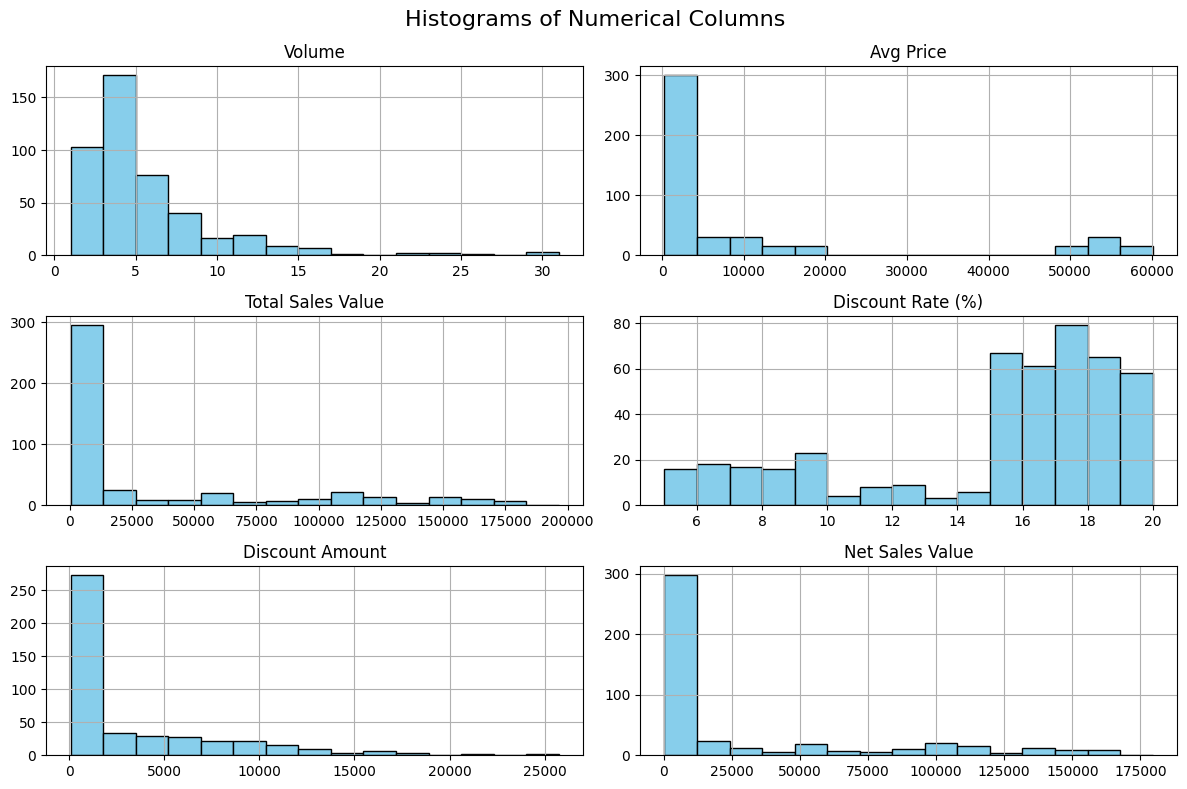

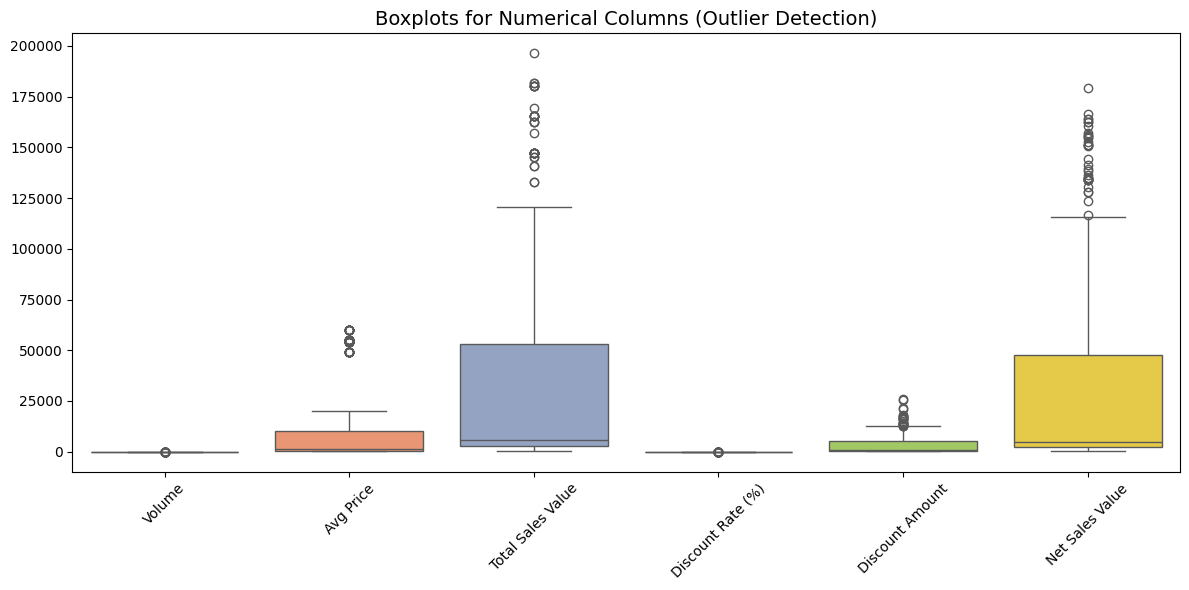

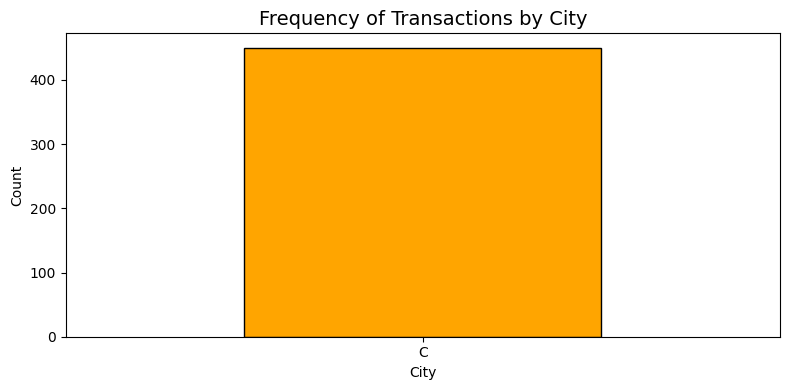

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset
df = pd.read_csv('sales_data_with_discounts.csv')

# Defining our numerical columns
num_cols = ['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']

# Code for Histograms
df[num_cols].hist(bins=15, figsize=(12, 8), color='skyblue', edgecolor='black')
plt.suptitle('Histograms of Numerical Columns', fontsize=16)
plt.tight_layout()
plt.show()

# Code for Boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols], palette="Set2")
plt.title('Boxplots for Numerical Columns (Outlier Detection)', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Code for Bar Chart
plt.figure(figsize=(8, 4))
df['City'].value_counts().plot(kind='bar', color='orange', edgecolor='black')
plt.title('Frequency of Transactions by City', fontsize=14)
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The following is the mathematical/statistical explanation of Step 2:

Skewness of Distribution: The histograms exhibit right skewness ( $\text{mean}>\text{median}$ ) throughout the financial variables, indicating that there is a non-normal distribution that exhibits positive skewness.

 Interquartile Range and Outliers: The boxplots show the Interquartile Range ( $\text{IQR}=Q_3-Q_1$ ) and detect the presence of severe upper bound outliers greater than ( $Q_3+1.5\times \text{IQR}$ ).

**Step 3: Z-Score Normalization (Feature Scaling)**

Description:

Converts the numeric features into a normalized Gaussian distribution ($\mu = 0, \sigma = 1$) through the transformation $z = \frac{x - \mu}{\sigma}$.


In [10]:
import pandas as pd

# Loading the dataset
df = pd.read_csv('sales_data_with_discounts.csv')

# Defining numerical columns
num_cols = ['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']

# Applying Z-score standar.
df_scaled = df.copy()
for col in num_cols:
    mean_val = df[col].mean()
    std_val = df[col].std()
    df_scaled[col] = (df[col] - mean_val) / std_val

# Showing 'before' vs 'after' comparison
print("  BEFORE STANDARDIZATION i.e(Original Data) ")
print(df[num_cols].head())

print("\n AFTER STANDARDIZATION (Z-Score Scaled Data) ")
print(df_scaled[num_cols].head())

  BEFORE STANDARDIZATION i.e(Original Data) 
   Volume  Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0      15      12100             181500          11.654820     21153.498820   
1      10      10100             101000          11.560498     11676.102961   
2       7      16100             112700           9.456886     10657.910157   
3       6      20100             120600           6.935385      8364.074702   
4       3       8100              24300          17.995663      4372.946230   

   Net Sales Value  
0    160346.501180  
1     89323.897039  
2    102042.089843  
3    112235.925298  
4     19927.053770  

 AFTER STANDARDIZATION (Z-Score Scaled Data) 
     Volume  Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0  2.347417   0.091072           2.922469          -0.829365         3.948422   
1  1.165831  -0.019548           1.329516          -0.851714         1.846958   
2  0.456880   0.312312           1.561038          -1.350129    

**Standardization (Z-Score Normalization)**
Concept: Transforms numeric columns such that their mean ($\mu$) becomes 0 and standard deviation ($\sigma$) becomes 1 to avoid values having larger numbers to dominate in analysis.Formula ($z = \frac{x - \mu}{\sigma}$):

$x$:Raw data point.

$\mu$: Mean of the column (Centers the data around 0)

$\sigma$: Standard deviation of the column (Standardizes the spread).

$z$: Score obtained (number of standard deviations away from the mean).

**Step 4: Transformation of Categorical Data to Dummy Variable (One Hot Encoding)**


Description: Converts categories in text form to binary numeric form (0 or 1) to prevent machines from making incorrect assumptions on mathematical ranks when analyzing data.

In [11]:
import pandas as pd

# Loading the dataset
df = pd.read_csv('sales_data_with_discounts.csv')

# Identifying categorical text columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Applying One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols)

# Displaying a portion of the transformed dataset
print(df_encoded.iloc[:, :10].head())

   Volume  Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0      15      12100             181500          11.654820     21153.498820   
1      10      10100             101000          11.560498     11676.102961   
2       7      16100             112700           9.456886     10657.910157   
3       6      20100             120600           6.935385      8364.074702   
4       3       8100              24300          17.995663      4372.946230   

   Net Sales Value  Date_01-04-2021  Date_02-04-2021  Date_03-04-2021  \
0    160346.501180             True            False            False   
1     89323.897039             True            False            False   
2    102042.089843             True            False            False   
3    112235.925298             True            False            False   
4     19927.053770             True            False            False   

   Date_04-04-2021  
0            False  
1            False  
2            False  
3 

**Explanation & Brief Description**


Concept:  Machine learning algorithms and mathematical models are unable to understand text data (i.e., categorical), which necessitates numeric data for processing. In One-Hot encoding, categorical text variables such as City and Category are converted to several binary variables which contain 0 and 1.

Process Involved: For every single category in the column, a new binary variable is created. The value of 1 is assigned to rows if they belong to that particular category, whereas 0 will be assigned otherwise. This technique enables algorithms to assess categorical variables without having any wrong mathematical ordering among them.

**Conclusion & Project Summary**

Key Finding Summary:

Through descriptive statistics and graphs, we find that critical financial measures such as (Avg Price, Sales Value Total, and Sales Value Net) show clear right-skewness with very large outliers due to their high value transactions ($\text{mean} > \text{median}$).

 On the contrary, the Distribution of Discount Rate (%) remains constant across all market segments.

 Reflection on Preprocessing of Data:


Z-Score Standardization: Vital in normalizing the scales of features ($\mu=0, \sigma=1$) in order to make sure that features with wide numeric ranges do not have an unbalanced influence on distance-based machine learning algorithms.


One-Hot Encoding: Vital in converting categorical text data (for example, City) to numeric binary data (0 or 1).